## Ejemplo simple de una Red Neuronal Convolucional

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np
import pandas as pd

In [3]:
torch.manual_seed(4)

función para graficar los parámetros de las capas convolucionales

In [4]:
def plot_channels(W):
    #number of output channels
    n_out=W.shape[0]
    #number of input channels
    n_in=W.shape[1]
    w_min=W.min().item()
    w_max=W.max().item()
    fig, axes = plt.subplots(n_out,n_in)
    fig.subplots_adjust(hspace = 0.1)
    out_index=0
    in_index=0
    #plot outputs as rows inputs as columns
    for ax in axes.flat:

        if in_index>n_in-1:
            out_index=out_index+1
            in_index=0

        ax.imshow(W[out_index,in_index,:,:], vmin=w_min, vmax=w_max, cmap='seismic')
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        in_index=in_index+1

    plt.show()

`show_data`: graficar una muestra de datos

In [5]:
def show_data(dataset,sample):

    plt.imshow(dataset.x[sample,0,:,:].numpy(),cmap='gray')
    plt.title('y='+str(dataset.y[sample].item()))
    plt.show()

crear algunos datos de juguete

In [6]:
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
    def __init__(self,N_images=100,offset=0,p=0.9, train=False):
        """
        p:portability that pixel is wight
        N_images:number of images
        offset:set a random vertical and horizontal offset images by a sample should be less than 3
        """
        if train==True:
            np.random.seed(1)

        #make images multiple of 3
        N_images=2*(N_images//2)
        images=np.zeros((N_images,1,11,11))
        start1=3
        start2=1
        self.y=torch.zeros(N_images).type(torch.long)

        for n in range(N_images):
            if offset>0:

                low=int(np.random.randint(low=start1, high=start1+offset, size=1))
                high=int(np.random.randint(low=start2, high=start2+offset, size=1))
            else:
                low=4
                high=1

            if n<=N_images//2:
                self.y[n]=0
                images[n,0,high:high+9,low:low+3]= np.random.binomial(1, p, (9,3))
            elif  n>N_images//2:
                self.y[n]=1
                images[n,0,low:low+3,high:high+9] = np.random.binomial(1, p, (3,9))



        self.x=torch.from_numpy(images).type(torch.FloatTensor)
        self.len=self.x.shape[0]
        del(images)
        np.random.seed(0)
    def __getitem__(self,index):
        return self.x[index],self.y[index]
    def __len__(self):
        return self.len

`plot_activation`: graficar las activaciones de las capas convolucionales

In [7]:
def plot_activations(A,number_rows= 1,name=""):
    A=A[0,:,:,:].detach().numpy()
    n_activations=A.shape[0]


    print(n_activations)
    A_min=A.min().item()
    A_max=A.max().item()

    if n_activations==1:

        # Plot the image.
        plt.imshow(A[0,:], vmin=A_min, vmax=A_max, cmap='seismic')

    else:
        fig, axes = plt.subplots(number_rows, n_activations//number_rows)
        fig.subplots_adjust(hspace = 0.4)
        for i,ax in enumerate(axes.flat):
            if i< n_activations:
                # Set the label for the sub-plot.
                ax.set_xlabel( "activation:{0}".format(i+1))

                # Plot the image.
                ax.imshow(A[i,:], vmin=A_min, vmax=A_max, cmap='seismic')
                ax.set_xticks([])
                ax.set_yticks([])
    plt.show()

Función utilitaria para calcular la salida de las convoluciones
toma una tupla de (h, w) y devuelve una tupla de (h, w)


In [8]:

def conv_output_shape(h_w, kernel_size=1, stride=1, pad=0, dilation=1):
    #by Duane Nielsen
    from math import floor
    if type(kernel_size) is not tuple:
        kernel_size = (kernel_size, kernel_size)
    h = floor( ((h_w[0] + (2 * pad) - ( dilation * (kernel_size[0] - 1) ) - 1 )/ stride) + 1)
    w = floor( ((h_w[1] + (2 * pad) - ( dilation * (kernel_size[1] - 1) ) - 1 )/ stride) + 1)
    return h, w

### Preparar datos

Carga el entrenamiento con 1000 ejemplos

In [9]:
N_images=10000
train_dataset=Data(N_images=N_images)

Carga el dataset de prueba

In [10]:
validation_dataset=Data(N_images=1000,train=False)
validation_dataset

podemos ver que el tipo de dato es largo

### Visualización de datos

Cada elemento en el **tensor rectangular** corresponde a un número que representa la **intensidad de un píxel**, como se muestra en la siguiente imagen.


Podemos imprimir la tercer etiqueta

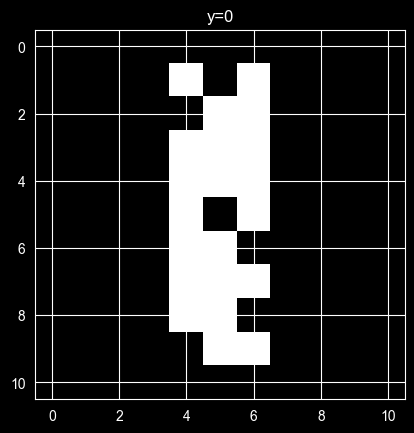

In [11]:
show_data(train_dataset,0)

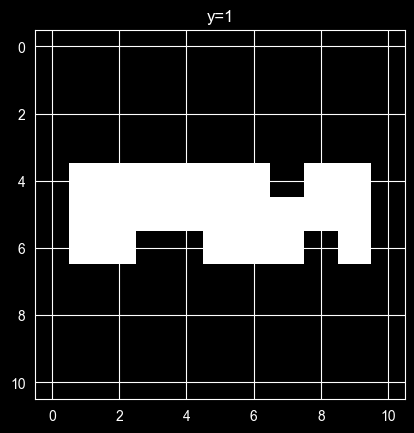

In [12]:
show_data(train_dataset,N_images//2+2)

Podemos imprimir el tercer ejemplo

### Construir una Red Neuronal Convolucional


La imagen de entrada es 11 × 11, lo siguiente cambiará el tamaño de las activaciones:

<ul> <li>capa convolucional</li> </ul> <ul> <li>capa de max pooling</li> </ul> <ul> <li>capa convolucional</li> </ul> <ul> <li>capa de max pooling</li> </ul>

con los siguientes parámetros: kernel_size, stride y pad.

Usamos las siguientes líneas de código para modificar la imagen antes de llegar a la capa completamente conectada.

In [13]:
out=conv_output_shape((11,11), kernel_size=2, stride=1, pad=0, dilation=1)
print(out)
out1=conv_output_shape(out, kernel_size=2, stride=1, pad=0, dilation=1)
print(out1)
out2=conv_output_shape(out1, kernel_size=2, stride=1, pad=0, dilation=1)
print(out2)

out3=conv_output_shape(out2, kernel_size=2, stride=1, pad=0, dilation=1)
print(out3)

(10, 10)
(9, 9)
(8, 8)
(7, 7)


Construir una clase de Red Neuronal Convolucional con dos capas convolucionales y una capa completamente conectada.

Predeterminar el tamaño de la matriz de salida final.

Los parámetros en el constructor son el número de canales de salida para la primera y la segunda capa.

In [14]:
class CNN(nn.Module):
    def __init__(self,out_1=2,out_2=1):

        super(CNN,self).__init__()
        #first Convolutional layers
        self.cnn1=nn.Conv2d(in_channels=1,out_channels=out_1,kernel_size=2,padding=0)
        self.maxpool1=nn.MaxPool2d(kernel_size=2 ,stride=1)

        #second Convolutional layers
        self.cnn2=nn.Conv2d(in_channels=out_1,out_channels=out_2,kernel_size=2,stride=1,padding=0)
        self.maxpool2=nn.MaxPool2d(kernel_size=2 ,stride=1)
        #max pooling

        #fully connected layer
        self.fc1=nn.Linear(out_2*7*7,2)

    def forward(self,x):
        #first Convolutional layers
        x=self.cnn1(x)
        #activation function
        x=torch.relu(x)
        #max pooling
        x=self.maxpool1(x)
        #first Convolutional layers
        x=self.cnn2(x)
        #activation function
        x=torch.relu(x)
        #max pooling
        x=self.maxpool2(x)
        #flatten output
        x=x.view(x.size(0),-1)
        #fully connected layer
        x=self.fc1(x)
        return x

    def activations(self,x):
        #outputs activation this is not necessary just for fun
        z1=self.cnn1(x)
        a1=torch.relu(z1)
        out=self.maxpool1(a1)

        z2=self.cnn2(out)
        a2=torch.relu(z2)
        out=self.maxpool2(a2)
        out=out.view(out.size(0),-1)
        return z1,a1,z2,a2,out

### Definir el clasificador de Red Neuronal Convolucional, la función de criterio, el optimizador y entrenar el modelo.


Hay 2 canales de salida para la primera capa y 1 canal de salida para la segunda capa.


In [15]:
model=CNN(2,1)

podemos ver los parámetros del modelo con el objeto

In [16]:
model

CNN(
  (cnn1): Conv2d(1, 2, kernel_size=(2, 2), stride=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(2, 1, kernel_size=(2, 2), stride=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=49, out_features=2, bias=True)
)

Graficar los parámetros del modelo para los kernels antes de entrenarlos. Los kernels se inicializan aleatoriamente.


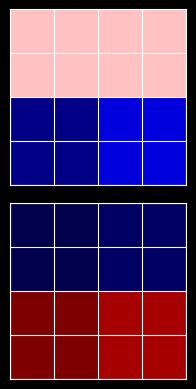

In [17]:
plot_channels(model.state_dict()['cnn1.weight'])

Funcion de perdida

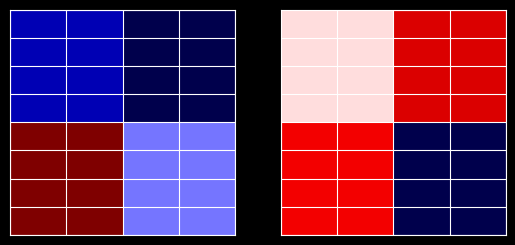

In [18]:
plot_channels(model.state_dict()['cnn2.weight'])

Define la función de perdida:

In [19]:
criterion=nn.CrossEntropyLoss()

Clase de optimización

In [20]:
learning_rate=0.001

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Define la clase de optimización

In [21]:
train_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=10)
validation_loader=torch.utils.data.DataLoader(dataset=validation_dataset,batch_size=20)

Entrenar el modelo y determinar la precisión de validación, técnicamente la precisión de prueba (esto puede tomar mucho tiempo)


In [22]:
n_epochs=10
cost_list=[]
accuracy_list=[]
N_test=len(validation_dataset)
cost=0
#n_epochs
for epoch in range(n_epochs):
    cost=0
    for x, y in train_loader:


        #clear gradient
        optimizer.zero_grad()
        #make a prediction
        z=model(x)
        # calculate loss
        loss=criterion(z,y)
        # calculate gradients of parameters
        loss.backward()
        # update parameters
        optimizer.step()
        cost+=loss.item()
    cost_list.append(cost)


    correct=0
    #perform a prediction on the validation  data
    for x_test, y_test in validation_loader:

        z=model(x_test)
        _,yhat=torch.max(z.data,1)

        correct+=(yhat==y_test).sum().item()


    accuracy=correct/N_test

    accuracy_list.append(accuracy)

### Analísis de resultados

Graficar la pérdida y la precisión en los datos de validación:

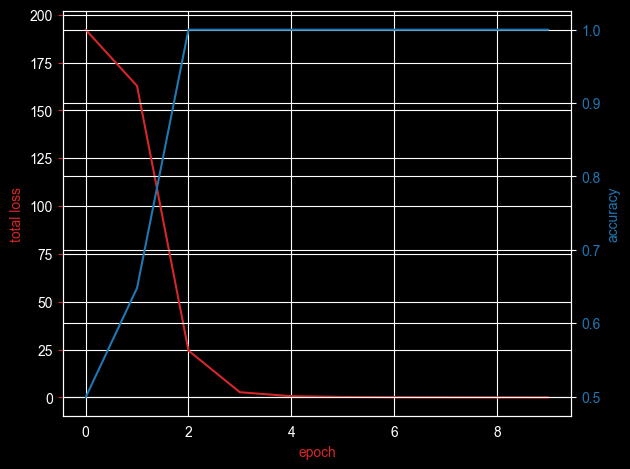

In [23]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(cost_list,color=color)
ax1.set_xlabel('epoch',color=color)
ax1.set_ylabel('total loss',color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()

Ver los resultados de los parámetros de las capas convolucionales.

In [24]:
model.state_dict()['cnn1.weight']

tensor([[[[ 0.3432,  0.4631],
          [-0.1322, -0.1908]]],


        [[[-0.4245, -0.2775],
          [ 0.9406,  0.8804]]]])

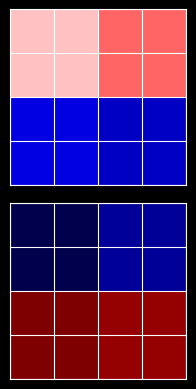

In [25]:
plot_channels(model.state_dict()['cnn1.weight'])

In [26]:
model.state_dict()['cnn1.weight']

tensor([[[[ 0.3432,  0.4631],
          [-0.1322, -0.1908]]],


        [[[-0.4245, -0.2775],
          [ 0.9406,  0.8804]]]])

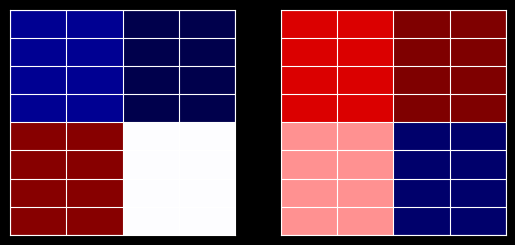

In [27]:
plot_channels(model.state_dict()['cnn2.weight'])

Considera el siguiente ejemplo

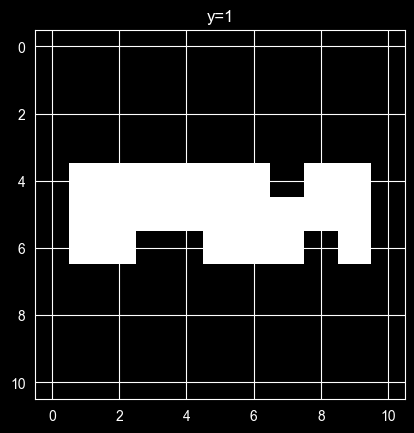

In [28]:
show_data(train_dataset,N_images//2+2)

Determina las activaciones

In [29]:
out=model.activations(train_dataset[N_images//2+2][0].view(1,1,11,11))
out=model.activations(train_dataset[0][0].view(1,1,11,11))

Graficalas

2


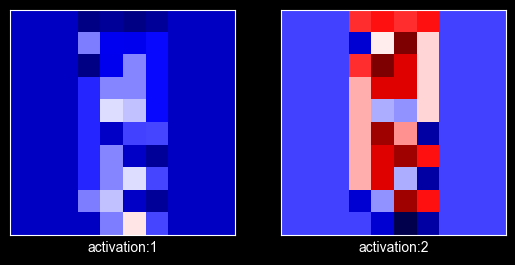

In [30]:
plot_activations(out[0],number_rows=1,name=" feature map")
plt.show()

1


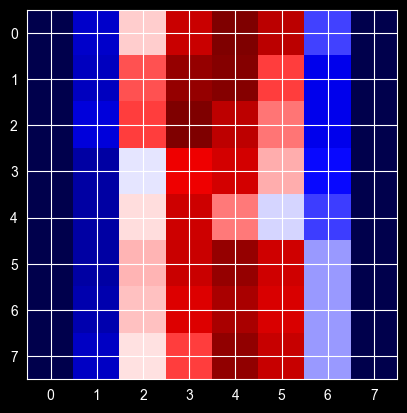

In [31]:
plot_activations(out[2],number_rows=1,name="2nd feature map")
plt.show()

1


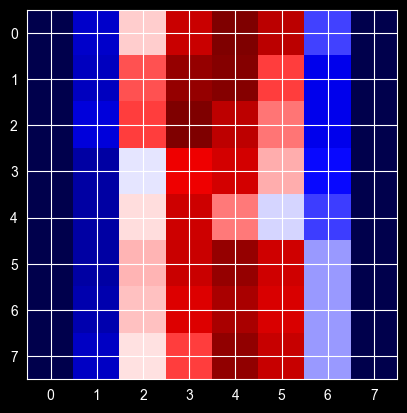

In [32]:
plot_activations(out[3],number_rows=1,name="first feature map")
plt.show()

guardamos la salida de la activación después de aplicar flatten

In [33]:
out1=out[4][0].detach().numpy()

Podemos hacer lo mismo para un ejemplo donde y=0

In [34]:
out0=model.activations(train_dataset[100][0].view(1,1,11,11))[4][0].detach().numpy()
out0

array([0.7362199 , 1.7856784 , 2.4640102 , 2.4640102 , 2.4540646 ,
       2.0330663 , 0.94921964, 0.59256583, 1.3520253 , 2.0127015 ,
       2.2133136 , 2.2133136 , 1.8477448 , 0.8492351 , 0.59256583,
       1.4245248 , 2.0127015 , 2.2133136 , 2.2133136 , 1.8477448 ,
       0.940636  , 0.62496066, 1.4245248 , 1.9847188 , 2.1877632 ,
       2.1877632 , 1.7651098 , 1.0406204 , 0.62496066, 1.3996899 ,
       1.9370118 , 2.106932  , 2.106932  , 1.7995154 , 1.0406204 ,
       0.6961152 , 1.694043  , 2.1798553 , 2.1798553 , 2.106932  ,
       1.7995154 , 0.94921964, 0.8216138 , 1.694043  , 2.1798553 ,
       2.1798553 , 2.0671206 , 1.6563593 , 0.8492351 ], dtype=float32)

Text(0, 0.5, 'Activation')

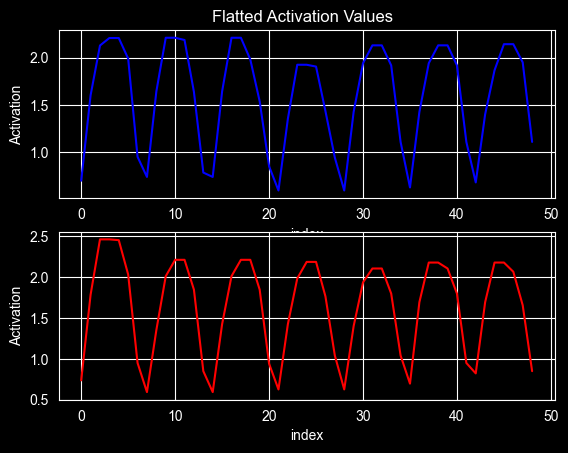

In [35]:
plt.subplot(2, 1, 1)
plt.plot( out1, 'b')
plt.title('Flatted Activation Values  ')
plt.ylabel('Activation')
plt.xlabel('index')
plt.subplot(2, 1, 2)
plt.plot(out0, 'r')
plt.xlabel('index')
plt.ylabel('Activation')